In [6]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import math
import json
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)
from ultralytics import YOLO
from utils import *

In [7]:
model_path = os.path.join(os.path.dirname(os.getcwd()), 'models')
model = YOLO(os.path.join(model_path, "yolov8n.pt"))

In [8]:
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
vid_name =  'real_test'

True


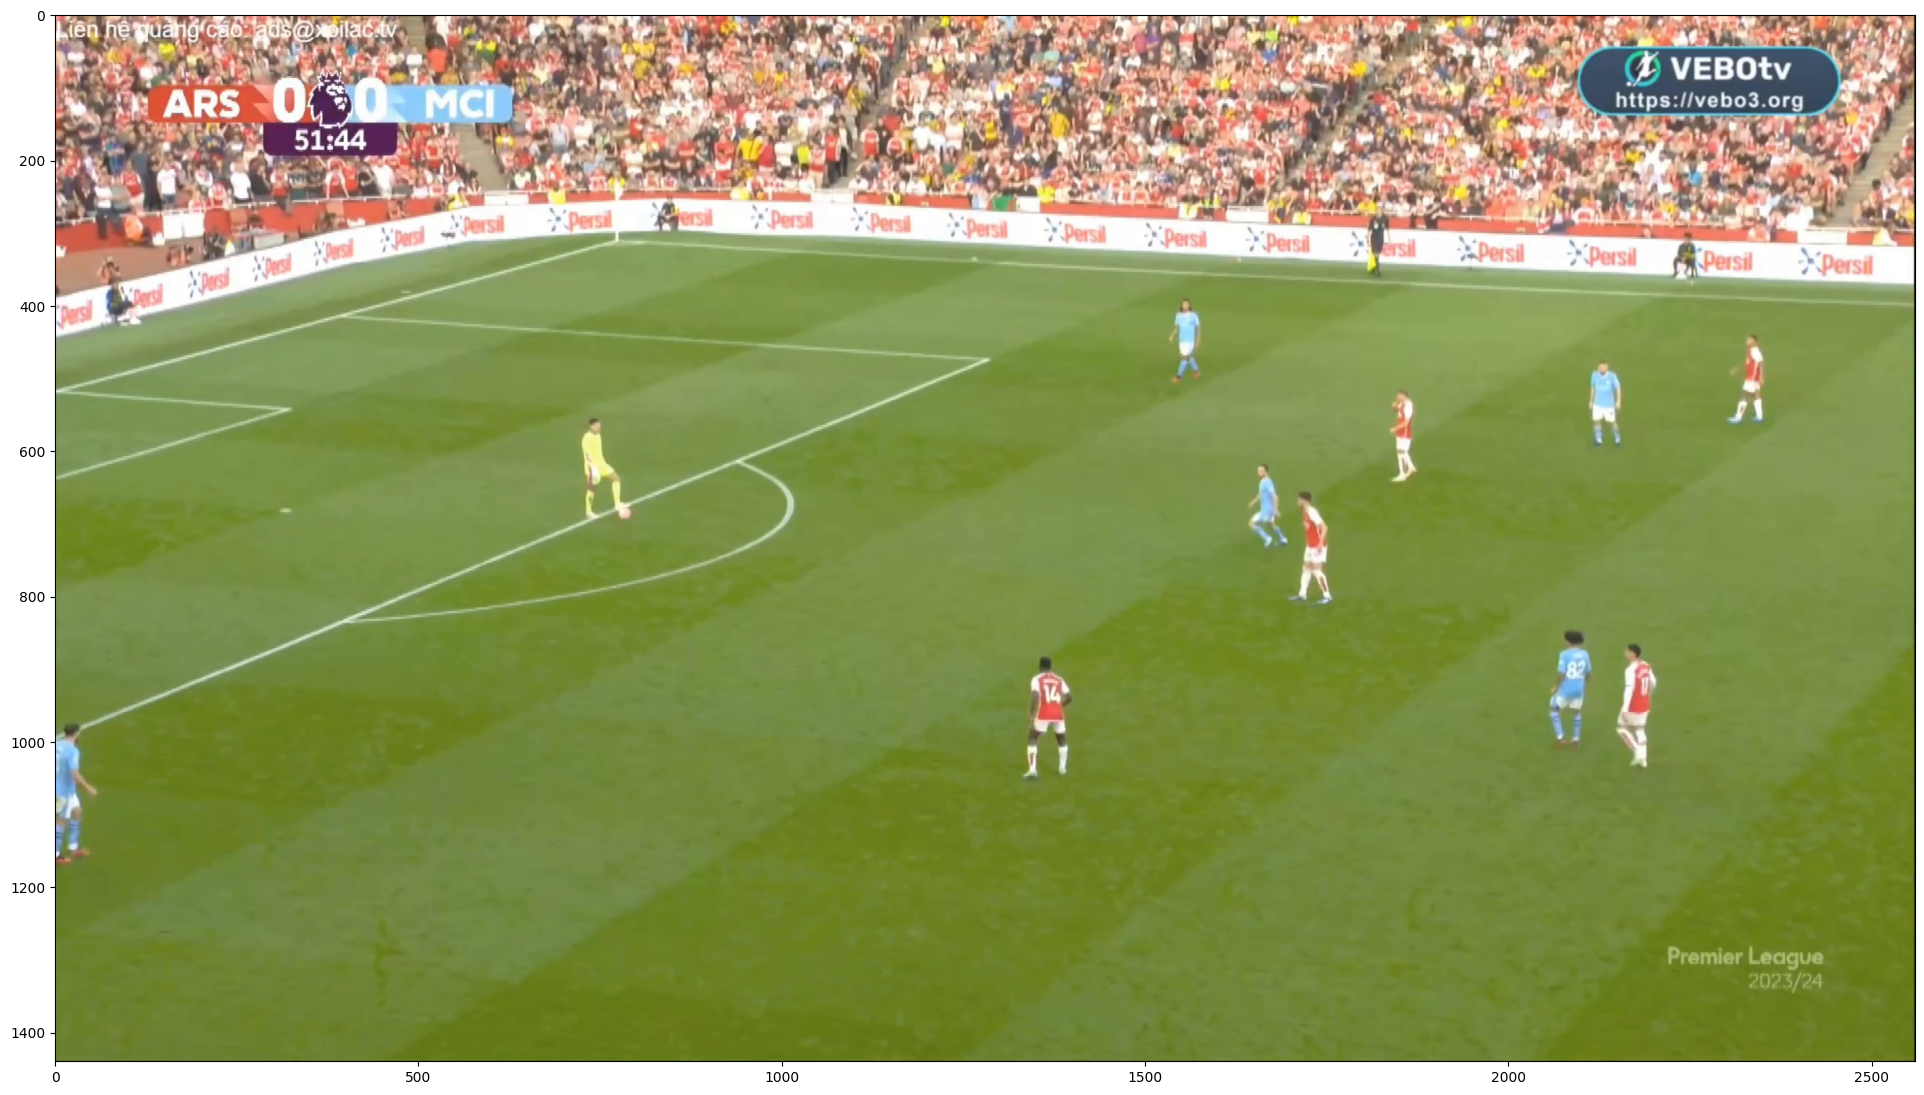

In [70]:
images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
images_path
image_path = os.path.join(images_path, os.listdir(images_path)[2])

rgb_image = cv2.imread(image_path, cv2.COLOR_BGR2RGB)

plt.figure()
plt.imshow(rgb_image[:,:,::-1])

[   0  296 2560 1144]


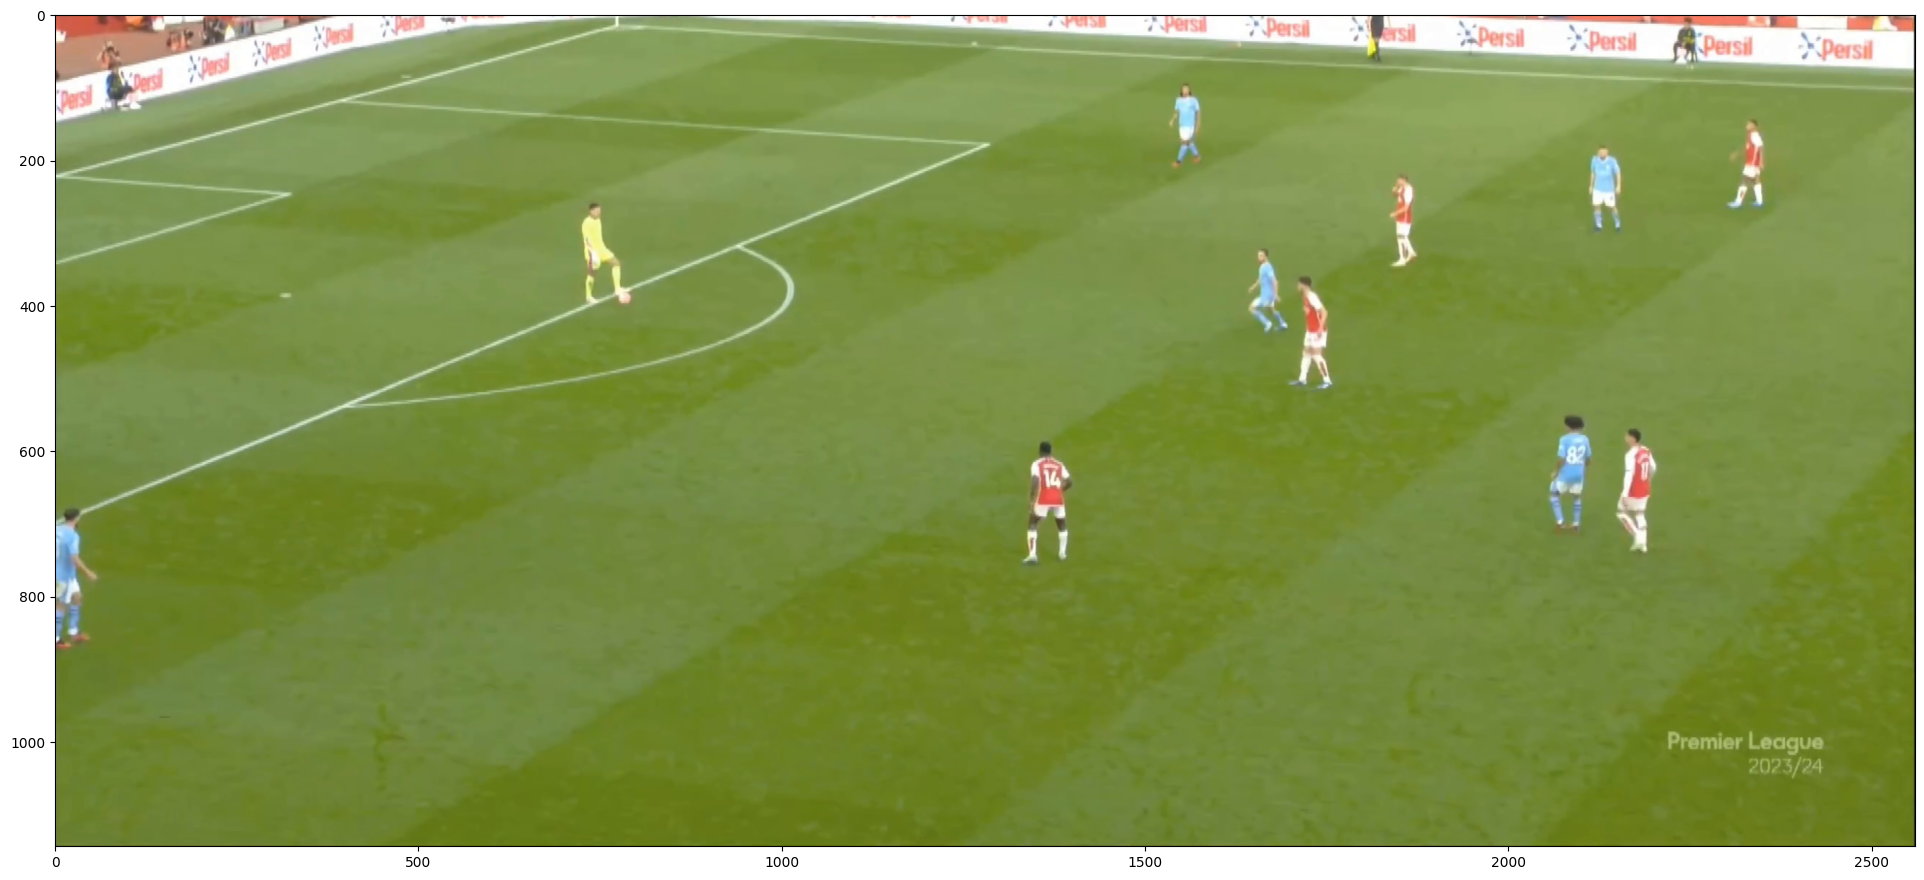

In [71]:
hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
lower_green = np.array([35, 20, 50])
upper_green = np.array([90, 255, 255])

mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
h, w, _ = result.shape
_, green, _ = cv2.split(temp)

#ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

contours = max(contours, key=cv2.contourArea)
rect = np.int16(cv2.boundingRect(contours))
min_x, min_y, w, h = rect
max_x, max_y = [min_x + w, min_y + h]
print(rect)
#cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

plt.imshow(temp[min_y:max_y, min_x:max_x])

# Crop the image
result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
plt.imshow(rgb_image[:,:,::-1])

In [126]:
first_batch = os.listdir(images_path)[0:1]
image_path = [os.path.join(images_path, x) for x in first_batch]
image_path

['/home/huy-ng/Project/Football-analysis/data/images/real_test/000000000130.png']

In [95]:
from sklearn.cluster import KMeans
from collections import Counter
from colormath.color_objects import sRGBColor, LabColor
from colormath.color_conversions import convert_color
from colormath.color_diff import delta_e_cie2000

images_path = os.path.join(data_path, 'images' + '/' + vid_name)
print(os.path.exists(images_path))
first_batch = os.listdir(images_path)[0:1]
image_batch = [os.path.join(images_path, x) for x in first_batch]        # Get several images to test

team_1_color_global = []
team_2_color_global = []
misc_color   = []
frame_num = 0


for image_ad in image_batch:
    rgb_image = cv2.imread(image_ad, cv2.COLOR_BGR2RGB)

    ## pitch seg
    hsv_image = cv2.cvtColor(rgb_image, cv2.COLOR_BGR2HSV)
    lower_green = np.array([35, 20, 50])
    upper_green = np.array([90, 255, 255])

    mask_green = cv2.inRange(hsv_image, lower_green, upper_green)
    result = cv2.bitwise_and(hsv_image, hsv_image, mask=mask_green)
    temp = cv2.cvtColor(result, cv2.COLOR_HSV2RGB)
    h, w, _ = result.shape
    _, green, _ = cv2.split(temp)

    #ret, thresh = cv2.threshold(temp, 150, 255, cv2.THRESH_BINARY)

    contours, hierarchy = cv2.findContours(image=green, mode=cv2.RETR_EXTERNAL,
                                      method=cv2.CHAIN_APPROX_NONE)

    contours = max(contours, key=cv2.contourArea)
    rect = np.int16(cv2.boundingRect(contours))
    min_x, min_y, w, h = rect
    max_x, max_y = [min_x + w, min_y + h]
    #cv2.polylines(img=temp, pts=[contours], isClosed=False, color=(255, 0, 0), thickness=5)
    cv2.rectangle(temp, (min_x, min_y), (max_x, max_y),color=(255, 0, 0), thickness=5)

    # Crop the image
    result = cv2.resize(result[min_y:max_y, min_x:max_x], (w, h))
    rgb_image = cv2.resize(rgb_image[min_y:max_y, min_x:max_x], (w, h))
    #plt.figure()
    #plt.imshow(rgb_image[:,:,::-1])
    ## run the model

    results = model.predict(rgb_image)
    boxes = results[0].boxes
    #print(boxes.cls)
    # Compute hue of grass
    grass_average = rgb_image[:,:,::-1].mean(axis=0).mean(axis=0)
    # Assignment 
    assignment=[]
    crop_img_list = []
    
    for box in boxes:
        if box.cls[0].item() == 0:   # if the person then continue to compute hue
            crop = box.xyxy
            (startX, startY, endX, endY) = np.concatenate(crop.cpu().detach().int().tolist())
            player_saved = rgb_image[startY:endY,startX:endX]
            crop_img_list.append(player_saved[:,:,::-1])
            # Z threshold% area of the box into account
            z = 0.6
            new_startY = round(startY + (1-np.sqrt(z))*(endY-startY)/2)
            new_endY = round(endY - (1-np.sqrt(z))*(endY-startY)/2)
            new_startX = round(startX + (1-np.sqrt(z))*(endX-startX)/2)
            new_endX = round(endX - (1-np.sqrt(z))*(endX-startX)/2)
            #--------------------
            cropped = rgb_image[new_startY:new_endY,new_startX:new_endX]
            test_crop = cropped[:,:,::-1].copy()
            result = []
            for row_idx in range(cropped.shape[0]):
                for col_idx in range(cropped.shape[1]):        
                    current_color = test_crop[row_idx][col_idx]
                    if sum(abs(current_color - grass_average)) > 60:
                        result.append(current_color)
            final_color = np.mean(result,axis = 0)
            assignment.append(final_color)

    kmeans = KMeans(n_clusters=3)
    s=kmeans.fit(assignment)
    labels=kmeans.labels_
    teams = Counter(labels).most_common(3)
    #print(teams)
    team_1 = np.where(labels == teams[0][0])[0]
    team_2 = np.where(labels == teams[1][0])[0]
    misc   = np.where(labels == teams[2][0])[0]


    
    #print(team_1_check)
    #print(team_2_check)
    #tester_pic_1 = crop_img_list[team_1[max_diff_team_1]] 
    #tester_pic_2 = crop_img_list[team_2[max_diff_team_2]] 
    #plt.figure()
    #plt.imshow(tester_pic_1)
    #plt.figure()
    #plt.imshow(tester_pic_2)


    if frame_num == 0:
        team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        misc_color.append(np.mean([assignment[i] for i in misc],axis = 0))
        # Double check the colors to see whether there is any discrepancy for first frame:
        #team_1_check = [np.linalg.norm(team_1_color-assignment[i]) for i in team_1]
        #team_2_check = [np.linalg.norm(team_2_color-assignment[i]) for i in team_2]
        #max_diff_team_1 = team_1_check.index(max(team_1_check))
        #max_diff_team_2 = team_2_check.index(max(team_2_check))
        #print(team_1_check)
        #print(team_2_check)
        #tester_pic_1 = crop_img_list[team_1[max_diff_team_1]] 
        #tester_pic_2 = crop_img_list[team_2[max_diff_team_2]] 
        #plt.figure()
        #plt.imshow(tester_pic_1)
        #plt.figure()
        #plt.imshow(tester_pic_2)

        # Metric CLE: Conversion -> Diff
        srgb_assignment = [sRGBColor(i[0], i[1], i[2]) for i in assignment]
        srgb_team_1_color = sRGBColor(team_1_color[0],team_1_color[1],team_1_color[2])
        srgb_team_2_color = sRGBColor(team_2_color[0],team_2_color[1],team_2_color[2])
        lab_assignment = [convert_color(x,LabColor) for x in srgb_assignment]
        lab_team_1_color = convert_color(srgb_team_1_color, LabColor)
        lab_team_2_color = convert_color(srgb_team_2_color, LabColor)
        team_1_color_global = lab_team_1_color 
        team_2_color_global = lab_team_2_color
        team_1_check = [delta_e_cie2000(lab_team_1_color, lab_assignment[i]) for i in team_1]
        team_2_check = [delta_e_cie2000(lab_team_2_color, lab_assignment[i]) for i in team_2]
        #max_diff_team_1_idx = team_1_check.index(max(team_1_check))
        #max_diff_team_2_idx = team_2_check.index(max(team_2_check))
        # Threshold to turn into Misc
        threshold_team_1 = np.mean(team_1_check) + np.std(team_1_check)
        threshold_team_2 = np.mean(team_2_check) + np.std(team_2_check)
        convert_misc_1_idx = [i for i in range(len(team_1_check)) if team_1_check[i] > threshold_team_1] 
        convert_misc_2_idx = [i for i in range(len(team_2_check)) if team_2_check[i] > threshold_team_2]

        if len(convert_misc_1_idx) > 0:
            for x in convert_misc_1_idx:
                labels[x] = teams[2][0]
                misc_color.append(assignment[x])
        if len(convert_misc_2_idx) > 0:
            for y in convert_misc_2_idx:
                labels[y] = teams[2][0]
                misc_color.append(assignment[y])
        
        labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
        labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels))
        print(labels)
        
    
    if frame_num > 0:
        team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        misc_color.append(np.mean([assignment[i] for i in misc],axis = 0))

        # Repetition to find the misc: Write the correct red
        srgb_assignment = [sRGBColor(i[0], i[1], i[2]) for i in assignment]
        srgb_team_1_color = sRGBColor(team_1_color[0],team_1_color[1],team_1_color[2])
        srgb_team_2_color = sRGBColor(team_2_color[0],team_2_color[1],team_2_color[2])
        lab_assignment = [convert_color(x,LabColor) for x in srgb_assignment]
        lab_team_1_color = convert_color(srgb_team_1_color, LabColor)
        lab_team_2_color = convert_color(srgb_team_2_color, LabColor)
        team_1_check = [delta_e_cie2000(lab_team_1_color, lab_assignment[i]) for i in team_1]
        team_2_check = [delta_e_cie2000(lab_team_2_color, lab_assignment[i]) for i in team_2]
        #max_diff_team_1_idx = team_1_check.index(max(team_1_check))
        #max_diff_team_2_idx = team_2_check.index(max(team_2_check))
        # Threshold to turn into Misc
        threshold_team_1 = np.mean(team_1_check) + np.std(team_1_check)
        threshold_team_2 = np.mean(team_2_check) + np.std(team_2_check)
        convert_misc_1_idx = [i for i in range(len(team_1_check)) if team_1_check[i] > threshold_team_1] 
        convert_misc_2_idx = [i for i in range(len(team_2_check)) if team_2_check[i] > threshold_team_2]

        if len(convert_misc_1_idx) > 0:
            for x in convert_misc_1_idx:
                labels[x] = teams[2][0]
                misc_color.append(assignment[x])
        if len(convert_misc_2_idx) > 0:
            for y in convert_misc_2_idx:
                labels[y] = teams[2][0]
                misc_color.append(assignment[y])

        # Update the label so that team X is always color Y 
        current_team_1_color = np.mean([assignment[i] for i in team_1],axis =0)
        current_team_2_color = np.mean([assignment[i] for i in team_2],axis =0)
        current_misc_color = np.mean([assignment[i] for i in misc],axis =0)
        
        if  diff_color_team_1_1 < diff_color_team_1_2:
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 2', labels))
        else: 
            labels = list(map(lambda x: x if x != teams[1][0] else 'Team 1', labels))
            labels = list(map(lambda x: x if x != teams[0][0] else 'Team 2', labels))

        #diff_misc_color = np.linalg.norm(team_1_color-current_misc_color)
        #labels = list(map(lambda x: x if x != teams[2][0] else 'Misc', labels)) # Comment this
        

    
        
    frame_num +=1

print(len(misc_color))
    
#diff_misc and further filtering and improvement of clustering:
# Case inspected after 60% reduction of area
# 1. Yello vs blue
# 2. only 2 cluster of colors
# 3. Maybe a quick run to see whether there is any color further away from the team color
# 4. Save new misc coors if poppedd up    
#print(diff_misc)


# Current task:
# Global vs local color save
# Misc color structure


0: 288x640 17 persons, 1 ball, 7.7ms
Speed: 12.5ms preprocess, 7.7ms inference, 1.0ms postprocess per image at shape (1, 3, 288, 640)


True
['Misc', 'Team 2', 'Team 2', 'Misc', 'Team 2', 'Misc', 'Team 1', 'Team 1', 'Team 1', 'Team 2', 'Team 1', 'Team 2', 'Team 1', 'Team 2', 'Team 1', 'Team 2', 'Team 1']
3


/home/huy-ng/Project/Football-analysis/.venv/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1412: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [168]:
labels = np.array(['Team 2', 'Team 2', 'Misc', 'Team 2', 'Misc', 'Team 1', 'Team 1', 'Team 1', 'Team 1', 'Misc'])
team_1_mod = np.where(labels == 'Team 1')
print(team_1_mod)

(array([5, 6, 7, 8]),)


In [58]:
!pip install colormath

  ERROR: Command errored out with exit status 1:
   command: /home/huy-ng/Project/Football-analysis/.venv/bin/python3 -u -c 'import sys, setuptools, tokenize; sys.argv[0] = '"'"'/tmp/pip-install-48t9a4v9/colormath/setup.py'"'"'; __file__='"'"'/tmp/pip-install-48t9a4v9/colormath/setup.py'"'"';f=getattr(tokenize, '"'"'open'"'"', open)(__file__);code=f.read().replace('"'"'\r\n'"'"', '"'"'\n'"'"');f.close();exec(compile(code, __file__, '"'"'exec'"'"'))' bdist_wheel -d /tmp/pip-wheel-z0sq_de6
       cwd: /tmp/pip-install-48t9a4v9/colormath/
  Complete output (6 lines):
  usage: setup.py [global_opts] cmd1 [cmd1_opts] [cmd2 [cmd2_opts] ...]
     or: setup.py --help [cmd1 cmd2 ...]
     or: setup.py --help-commands
     or: setup.py cmd --help
  
  error: invalid command 'bdist_wheel'
  ----------------------------------------
  ERROR: Failed building wheel for colormath
  Running setup.py clean for colormath
Failed to build colormath
    Running setup.py install for colormath ... done


In [71]:
# Red Color
color1_rgb = sRGBColor(1.0, 0.0, 0.0);

# Blue Color
color2_rgb = sRGBColor(0.0, 0.0, 1.0);

# Convert from RGB to Lab Color Space
color1_lab = convert_color(color1_rgb, LabColor);

# Convert from RGB to Lab Color Space
color2_lab = convert_color(color2_rgb, LabColor);

# Find the color difference
delta_e = delta_e_cie2000(color1_lab, color2_lab);

print ("The difference between the 2 color = ", delta_e)

The difference between the 2 color =  52.88009898346556


In [79]:
test_1 = [5.515201631567911, 15.198703983638413, 20.571191867856946, 45.50415708798051, 5.714887319599944, 26.893941278762274, 16.01699691061821, 9.819217559457474, 10.480740217970085]
test_2 = [15.208873593682302, 5.123934739907209, 20.138532797062926, 30.015656082601115, 26.61448881207698, 72.868181894459, 45.00607734138506]
print(np.mean(test_1) + np.std(test_1))
print(np.mean(test_2) + np.std(test_2))

29.22662658034855
51.43221419215469


In [70]:
import numpy

def patch_asscalar(a):
    return a.item()

setattr(numpy, "asscalar", patch_asscalar)